# PPO baseline on Four Rooms

In [1]:
from pathlib import Path
import sys
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt

# Resolve repository src path robustly when running notebook in-place.
repo_root = Path.cwd()
while repo_root != repo_root.parent and not (repo_root / 'src').exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root / 'src'))

from environments.fourrooms import FourRoomsGridWorld, FourRoomsGoalWrapper
from utils import TrajectoryReplayBuffer, collect_episode, evaluate_policy
from visualisations import plot_policy_rollouts, plot_q_diagnostics 
from agents import PPO_ActorCritic


DEVICE = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
print('Using device:', DEVICE)


Using device: mps


In [2]:
def make_env(goal=(9,9), slip_prob=0.00, max_horizon=500):
    base = FourRoomsGridWorld(room_size=5, max_episode_steps=max_horizon)
    env = FourRoomsGoalWrapper(
        base,
        goal_position=goal,
        goal_reward=1.0,
        step_reward=0.0,
        slip_prob=slip_prob,
    )
    return env

[PPO] step=  10240 | eval_return=0.000 | eval_len=500.0
[PPO] step=  20480 | eval_return=0.000 | eval_len=500.0
[PPO] step=  30720 | eval_return=0.375 | eval_len=321.0
[PPO] step=  40960 | eval_return=0.250 | eval_len=380.2
[PPO] step=  51200 | eval_return=0.375 | eval_len=331.5
[PPO] step=  61440 | eval_return=0.125 | eval_len=446.2
[PPO] step=  71680 | eval_return=0.375 | eval_len=322.1
[PPO] step=  81920 | eval_return=0.500 | eval_len=267.0
[PPO] step=  92160 | eval_return=0.625 | eval_len=211.1
[PPO] step= 102400 | eval_return=0.500 | eval_len=276.4
[PPO] step= 112640 | eval_return=0.625 | eval_len=199.1
[PPO] step= 122880 | eval_return=0.125 | eval_len=440.2
[PPO] step= 133120 | eval_return=0.375 | eval_len=336.5
[PPO] step= 143360 | eval_return=0.750 | eval_len=139.0
[PPO] step= 153600 | eval_return=0.875 | eval_len=84.2
[PPO] step= 163840 | eval_return=0.875 | eval_len=78.1
[PPO] step= 174080 | eval_return=0.750 | eval_len=142.4
[PPO] step= 184320 | eval_return=1.000 | eval_len=

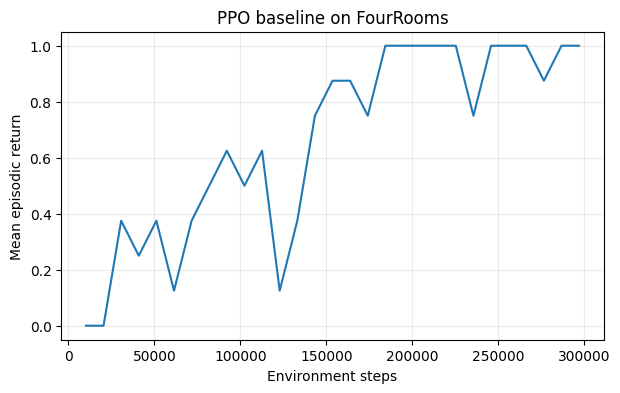

In [3]:


def ppo_train(total_steps=300000, rollout_steps=2048, gamma=0.99, gae_lambda=0.95, clip_ratio=0.2, pi_lr=3e-4, vf_coef=0.5, ent_coef=0.0, train_epochs=10, minibatch_size=256):
    
    env = make_env()
    obs_dim = env.observation_space.shape[0]
    act_dim = env.action_space.shape[0]
    model = PPO_ActorCritic(obs_dim, act_dim).to(DEVICE)
    opt = optim.Adam(model.parameters(), lr=pi_lr)

    obs, _ = env.reset()
    global_step = 0
    update_idx = 0
    eval_returns = []

    while global_step < total_steps:
        obs_buf, act_buf, logp_buf, rew_buf, done_buf, val_buf = [], [], [], [], [], []

        for _ in range(rollout_steps):
            obs_t = torch.tensor(obs, dtype=torch.float32, device=DEVICE).unsqueeze(0)
            with torch.no_grad():
                dist, v = model(obs_t)
                raw_a = dist.sample()
                logp = dist.log_prob(raw_a).sum(-1)
                act = torch.tanh(raw_a)

            act_np = act.squeeze(0).cpu().numpy().astype(np.float32)
            next_obs, rew, term, trunc, _ = env.step(act_np)
            done = term or trunc

            obs_buf.append(obs.copy())
            act_buf.append(act_np.copy())
            logp_buf.append(float(logp.item()))
            rew_buf.append(float(rew))
            done_buf.append(float(done))
            val_buf.append(float(v.item()))

            obs = next_obs
            global_step += 1
            if done:
                obs, _ = env.reset()
            if global_step >= total_steps:
                break

        # Bootstrap value
        obs_t = torch.tensor(obs, dtype=torch.float32, device=DEVICE).unsqueeze(0)
        with torch.no_grad():
            _, last_v = model(obs_t)
        last_v = float(last_v.item())

        # GAE-Lambda advantage
        adv = np.zeros(len(rew_buf), dtype=np.float32)
        gae = 0.0
        for t in reversed(range(len(rew_buf))):
            nonterminal = 1.0 - done_buf[t]
            next_v = last_v if t == len(rew_buf) - 1 else val_buf[t + 1]
            delta = rew_buf[t] + gamma * next_v * nonterminal - val_buf[t]
            gae = delta + gamma * gae_lambda * nonterminal * gae
            adv[t] = gae
        ret = adv + np.array(val_buf, dtype=np.float32)

        obs_t = torch.tensor(np.array(obs_buf), dtype=torch.float32, device=DEVICE)
        act_t = torch.tensor(np.array(act_buf), dtype=torch.float32, device=DEVICE)
        old_logp_t = torch.tensor(np.array(logp_buf), dtype=torch.float32, device=DEVICE)
        adv_t = torch.tensor(adv, dtype=torch.float32, device=DEVICE)
        ret_t = torch.tensor(ret, dtype=torch.float32, device=DEVICE)

        adv_t = (adv_t - adv_t.mean()) / (adv_t.std() + 1e-8)

        n = obs_t.shape[0]
        for _ in range(train_epochs):
            idx = np.random.permutation(n)
            for start in range(0, n, minibatch_size):
                mb = idx[start:start + minibatch_size]
                dist, v = model(obs_t[mb])

                # Invert tanh for approximate log-prob under Gaussian
                clipped = torch.clamp(act_t[mb], -0.999, 0.999)
                pre_tanh = 0.5 * torch.log((1 + clipped) / (1 - clipped))
                new_logp = dist.log_prob(pre_tanh).sum(-1)
                ratio = torch.exp(new_logp - old_logp_t[mb])

                pg1 = ratio * adv_t[mb]
                pg2 = torch.clamp(ratio, 1 - clip_ratio, 1 + clip_ratio) * adv_t[mb]
                policy_loss = -torch.min(pg1, pg2).mean()
                value_loss = F.mse_loss(v.squeeze(-1), ret_t[mb])
                entropy = dist.entropy().sum(-1).mean()

                loss = policy_loss + vf_coef * value_loss - ent_coef * entropy
                opt.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 0.5)
                opt.step()

        update_idx += 1
        if update_idx % 5 == 0:
            eval_env = make_env()
            mean_ret, mean_len = evaluate_policy(
                eval_env,
                lambda o: torch.tanh(
                    model(torch.tensor(o, dtype=torch.float32, device=DEVICE).unsqueeze(0))[0].mean
                ).squeeze(0).detach().cpu().numpy().astype(np.float32),
                episodes=8,
            )
            eval_returns.append((global_step, mean_ret))
            print(f'[PPO] step={global_step:7d} | eval_return={mean_ret:.3f} | eval_len={mean_len:.1f}')
            eval_env.close()

    env.close()
    return model, eval_returns


ppo_model, ppo_eval = ppo_train()

if ppo_eval:
    xs, ys = zip(*ppo_eval)
    plt.figure(figsize=(7, 4))
    plt.plot(xs, ys)
    plt.xlabel('Environment steps')
    plt.ylabel('Mean episodic return')
    plt.title('PPO baseline on FourRooms')
    plt.grid(alpha=0.25)
    plt.show()


## Visualisations

Episode 1: 3 steps | return: 1.00 | reached goal: True
Episode 2: 23 steps | return: 1.00 | reached goal: True
Episode 3: 8 steps | return: 1.00 | reached goal: True
Episode 4: 14 steps | return: 1.00 | reached goal: True
Episode 5: 22 steps | return: 1.00 | reached goal: True
Episode 6: 23 steps | return: 1.00 | reached goal: True
Episode 7: 5 steps | return: 1.00 | reached goal: True
Episode 8: 1 steps | return: 1.00 | reached goal: True

Success rate: 100.00% over 8 episodes
Average return: 1.00 ± 0.00


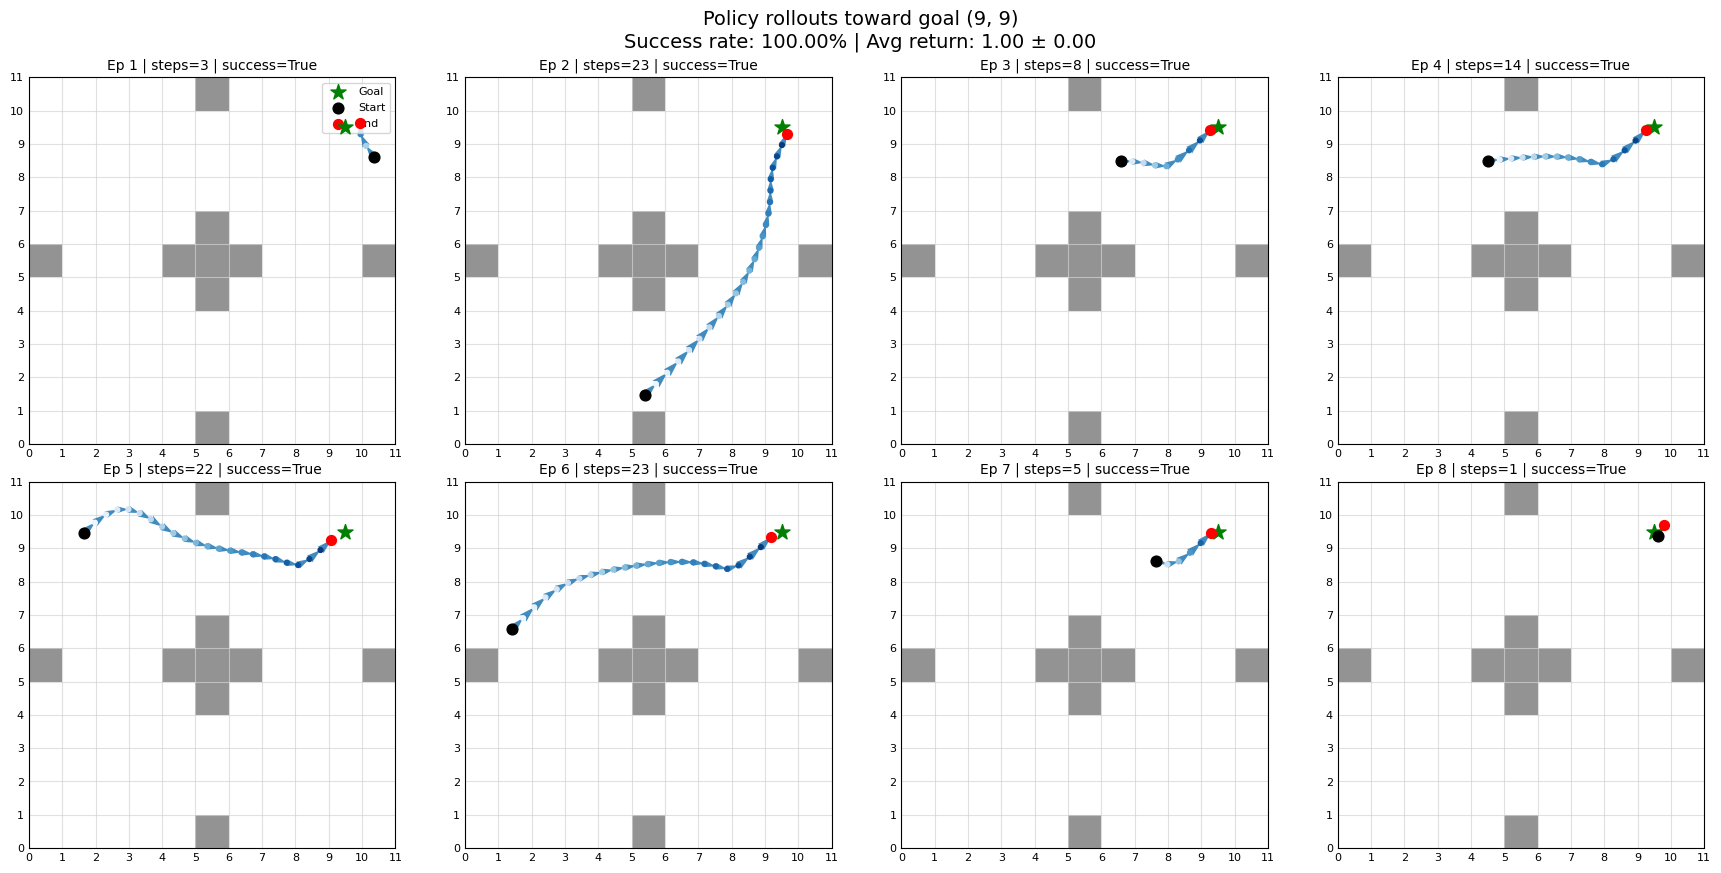

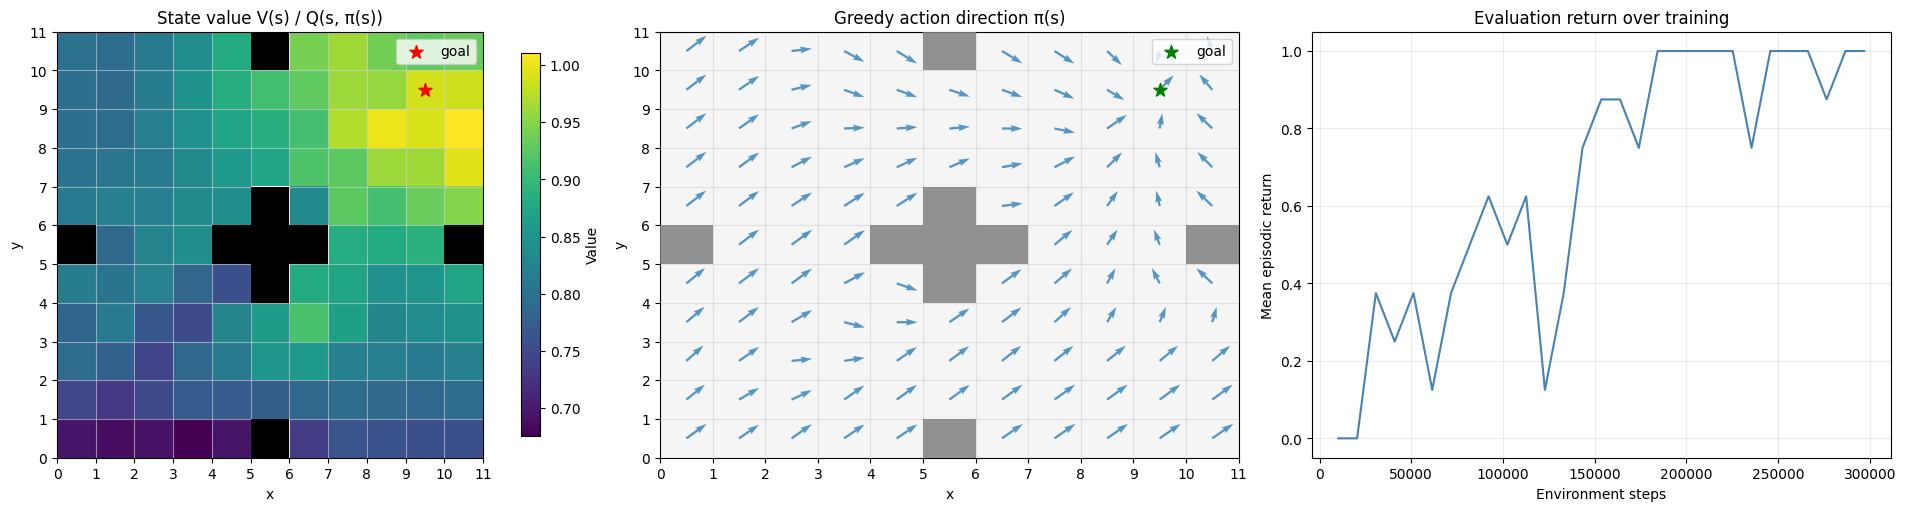

In [4]:

ppo_model.eval()
eval_env = make_env(goal=(9, 9))

def ppo_policy_fn(obs):
    obs_t = torch.tensor(obs, dtype=torch.float32, device=DEVICE).unsqueeze(0)
    with torch.no_grad():
        dist, _ = ppo_model(obs_t)
        action = torch.tanh(dist.mean).squeeze(0).cpu().numpy().astype(np.float32)
    return action


def ppo_value_fn(obs_batch):
    obs_t = torch.tensor(obs_batch, dtype=torch.float32, device=DEVICE)
    with torch.no_grad():
        _, v = ppo_model(obs_t)
    return v.squeeze(-1).cpu().numpy()


def ppo_actor_fn(obs_batch):
    obs_t = torch.tensor(obs_batch, dtype=torch.float32, device=DEVICE)
    with torch.no_grad():
        dist, _ = ppo_model(obs_t)
        actions = torch.tanh(dist.mean).cpu().numpy()
    return actions


plot_policy_rollouts(
    env=eval_env,
    policy_fn=ppo_policy_fn,
    goal_pos=(9, 9),
    eval_episodes=8,
    n_cols=4,
    is_discrete=False,
    step_point_size=12,
    start_size=60,
    end_size=50,
    goal_size=130,
    arrow_width=0.01,
)

eval_env.close()

eval_env = make_env(goal=(9, 9))

plot_q_diagnostics(
    env=eval_env,
    value_fn=ppo_value_fn,
    actor_fn=ppo_actor_fn,
    is_discrete=False,
    goal_pos=(9, 9),
    eval_returns=ppo_eval,
)

eval_env.close()